In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from mlxtend.plotting import plot_decision_regions

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/gsampathkumar01/placement/placement.csv


In [3]:
df = pd.read_csv("/kaggle/input/datasets/gsampathkumar01/placement/placement.csv")
df

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [5]:
df.drop('Unnamed: 0' , axis = 1 , inplace = True , errors = 'ignore')
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


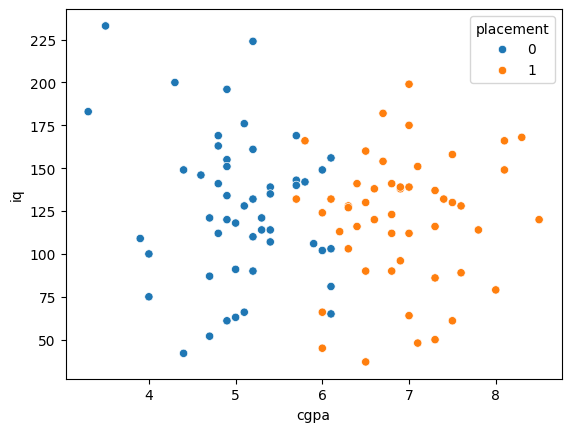

In [6]:
sns.scatterplot(
    x = df['cgpa'] ,
    y = df['iq'] ,
    hue = df['placement']
) 
plt.show()

In [7]:
X=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [8]:
X.shape

(100, 2)

In [9]:
y.shape

(100,)

train test split

In [10]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.1)

In [11]:
X_train , X_test , y_train , y_test 

(    cgpa     iq
 74   6.7  154.0
 14   6.1  103.0
 44   7.5   61.0
 66   6.9   96.0
 72   7.3  116.0
 ..   ...    ...
 87   5.7  132.0
 99   6.2  113.0
 11   6.9  138.0
 55   7.8  114.0
 49   5.4  135.0
 
 [90 rows x 2 columns],
     cgpa     iq
 53   8.3  168.0
 15   5.1  176.0
 46   5.3  114.0
 2    5.3  121.0
 71   6.1  132.0
 5    7.1   48.0
 61   7.3  137.0
 1    5.9  106.0
 42   7.6   89.0
 97   6.7  182.0,
 74    1
 14    0
 44    1
 66    1
 72    1
      ..
 87    1
 99    1
 11    1
 55    1
 49    0
 Name: placement, Length: 90, dtype: int64,
 53    1
 15    0
 46    0
 2     0
 71    1
 5     1
 61    1
 1     0
 42    1
 97    1
 Name: placement, dtype: int64)

scaling the values

In [12]:
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_train

array([[ 0.67112365,  0.77558079],
       [ 0.1428339 , -0.50727176],
       [ 1.37551   , -1.56373857],
       [ 0.84722024, -0.68334956],
       [ 1.19941341, -0.18027013],
       [-0.82569732, -1.51343063],
       [ 0.49502707,  0.92650462],
       [-1.70618025, -1.21158297],
       [-1.70618025, -0.58273368],
       [-0.82569732, -0.12996219],
       [ 0.31893048,  0.09642356],
       [ 0.58307536, -0.07965424],
       [-2.3225183 ,  1.50504597],
       [ 1.90379975,  1.07742845],
       [-0.20935927,  0.42342519],
       [ 0.93526853,  1.90750951],
       [-0.91374562, -1.56373857],
       [-1.0898422 , -1.79012431],
       [-1.0898422 , -0.05450027],
       [-0.47350415,  0.39827122],
       [-0.12131098,  1.07742845],
       [-1.17789049,  0.57434902],
       [-0.12131098,  0.47373313],
       [-1.79422854, -0.35634793],
       [-0.20935927,  1.15289037],
       [ 0.1428339 ,  0.82588873],
       [ 1.46355829,  0.12157753],
       [-1.00179391,  1.15289037],
       [-0.64960074,

In [13]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

X_test = scalar.transform(X_test)

model training

In [14]:
clf = LogisticRegression()

In [15]:
clf.fit(X_train , y_train)

LogisticRegression()

In [16]:
y_pred = clf.predict(X_test)
y_pred

array([1, 0, 0, 0, 1, 1, 1, 0, 1, 1])

In [17]:
y_test

53    1
15    0
46    0
2     0
71    1
5     1
61    1
1     0
42    1
97    1
Name: placement, dtype: int64

In [18]:
accuracy_score(y_test ,  y_pred)

1.0

<Axes: >

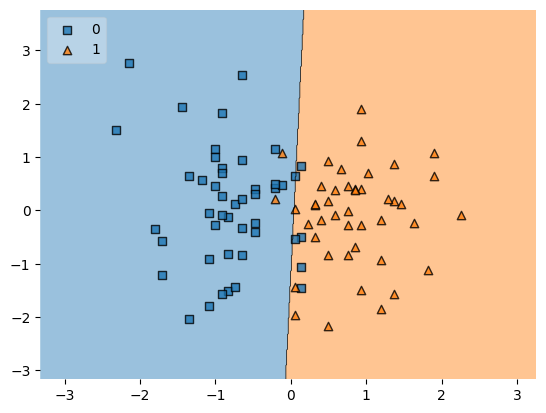

In [19]:
plot_decision_regions(X_train , y_train.values , clf=clf ,legend=2)

In [20]:
with open('toydata.pkl', 'wb') as file:
    pickle.dump(clf, file)